#Project in Pattern Recognition and Machine Learning
##kNN & PCA on the Dry Bean Dataset

## *Aleksandar Horvat i Dunja Tomašević*

# Obrada podataka i eksplorativna analiza

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import precision_score, recall_score, f1_score
import time


df = pd.read_excel('Dry_Bean_Dataset.xlsx')


In [56]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Osnovne informacije

Kao deo standardne prakse proveravaju se osnovne informacije o skupu, nedostajuće vrednosti i duplikati.

In [57]:
df.shape

(13611, 17)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

## Nedostajuće vrednosti

In [59]:
missing = df.isnull().sum().sum()
print(missing)


0


## Duplikati

In [60]:
n_dup = df.duplicated().sum()
print(n_dup)

68


In [61]:
df = df.drop_duplicates()
print(df.shape)

(13543, 17)


## Deskriptivna statistika

In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13543.0,53048.460385,29392.438324,20420.000000,36282.500000,44580.000000,61382.000000,254616.000000
Perimeter,13543.0,854.993406,214.722684,524.736000,703.230000,793.896000,977.146500,1985.370000
MajorAxisLength,13543.0,319.895602,85.809260,183.601165,253.086806,296.404589,376.312489,738.860153
MinorAxisLength,13543.0,202.365321,45.051632,122.512653,175.886357,192.491117,217.245403,460.198497
AspectRation,13543.0,1.581075,0.245245,1.024868,1.430662,1.549860,1.703916,2.430306
Eccentricity,13543.0,0.750315,0.091858,0.218951,0.715144,0.763997,0.809671,0.911423
ConvexArea,13543.0,53767.986709,29844.248525,20684.000000,36673.000000,45122.000000,62360.000000,263261.000000
EquivDiameter,13543.0,253.034094,59.307709,161.243764,214.933277,238.245711,279.560351,569.374358
Extent,13543.0,0.749829,0.048939,0.555315,0.718735,0.759903,0.786849,0.866195
Solidity,13543.0,0.987152,0.004650,0.919246,0.985678,0.988288,0.990019,0.994677


Atributi imaju izrazito različite skale (`Area` u hiljadama, `Eccentricity` izmedju 0 i 1). Budući da kNN i weighted kNN  koriste
euklidsku udaljenost važno će biti date podatke standardizovati.

## Zastupljenost klasa

Nebalansiranost klasa direktno utice na kNN, kao i na weighted kNN, stoga je važno i ovo proveriti.

In [63]:
print(len(df['Class'].unique()))

7


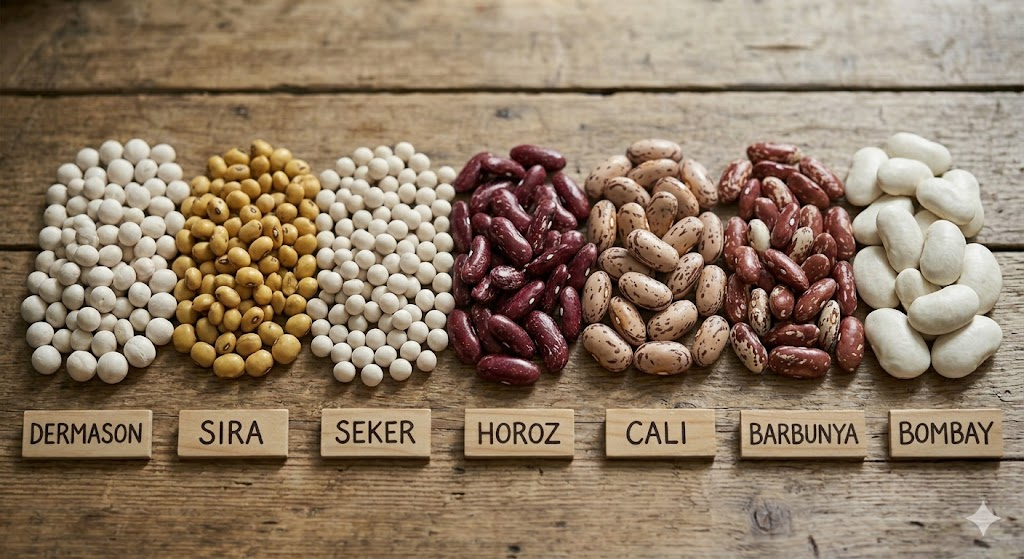

In [64]:
class_counts = df['Class'].value_counts()
print(class_counts)


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [65]:
print(f'Odnos najveće i najmanje klase: {class_counts.max() / class_counts.min():.1f}x')

Odnos najveće i najmanje klase: 6.8x


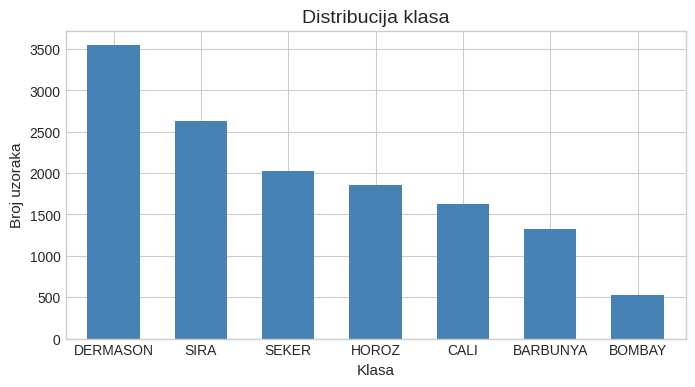

In [66]:
plt.figure(figsize=(8, 4))

plt.style.use('seaborn-v0_8-whitegrid') # ovako su lepsi malo grafici
class_counts.plot(kind='bar', color='#4682B4', width=0.6)

plt.title('Distribucija klasa', fontsize=14)
plt.xlabel('Klasa', fontsize=11)
plt.ylabel('Broj uzoraka', fontsize=11)
plt.xticks(rotation=0)

plt.show()


Skup nije savršeno balansiran, stoga ćemo pratiti i dodatne metrike pored tačnosti koje su naročito korisne u ovakvim slučajevima.

## Distribucija atributa

Raspodele atributa posmatramo jer PCA i kNN su osetljivi na ekstremne vrednosti. PCA formira kovarijansnu matricu, pa ako jedan uzorak ima neobično veliku vrednost, ta vrednost "navuče" varijansu ka sebi. kNN koristi euklidsku udaljenost, autlajer je *narušava* i kvari glasanje suseda. Zbog toga posmatramo da li distribucije imaju duge repove ili jako iskošen oblik.

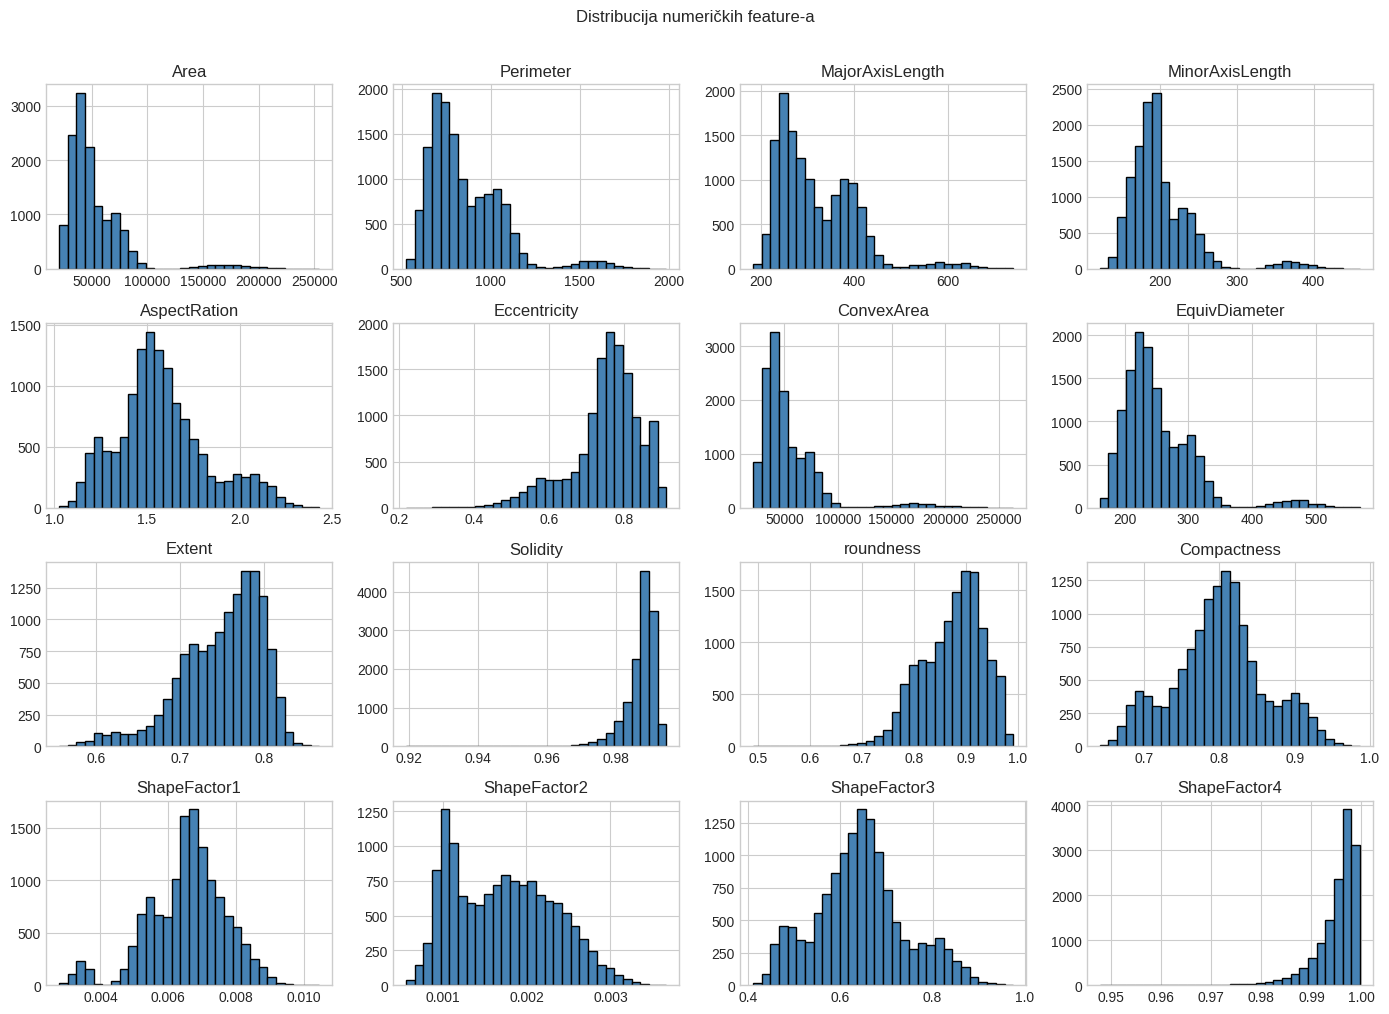

In [67]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(14, 10), bins=30, edgecolor='black', color='steelblue')
plt.suptitle('Distribucija numeričkih feature-a', y=1.01)
plt.tight_layout()
plt.show()


Posmatrajući distribucije, uočavamo da atributi koji opisuju fizičke dimenzije zrna — `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea` i `EquivDiameter` — pokazuju pozitivnu iskošenost sa dugačkim desnim repom. `AspectRation`, `Eccentricity` i `ShapeFactor2` pokazuju bimodalnu distribuciju sa dva vidljiva vrha. Relativno normalna raspodela je prisutna kod `Roundness`, `Compactness`, `ShapeFactor3`

Zbog iskošenosti prvonavedenih atributa, u nastavku ćemo uporediti dve verzije analize: jednu na originalnim standardizovanim podacima i jednu gde pre standardizacije primenimo log-transformaciju na pomenute feature-e kako bi se umanjio uticaj osobina datih distribucija.

## Korelaciona matrica

Zgodno je videti generalno matricu korelacije, pre nego što primenimo metodu redukcije dimenzionalnosti (PCA) koja zahteva korelisanost podataka.

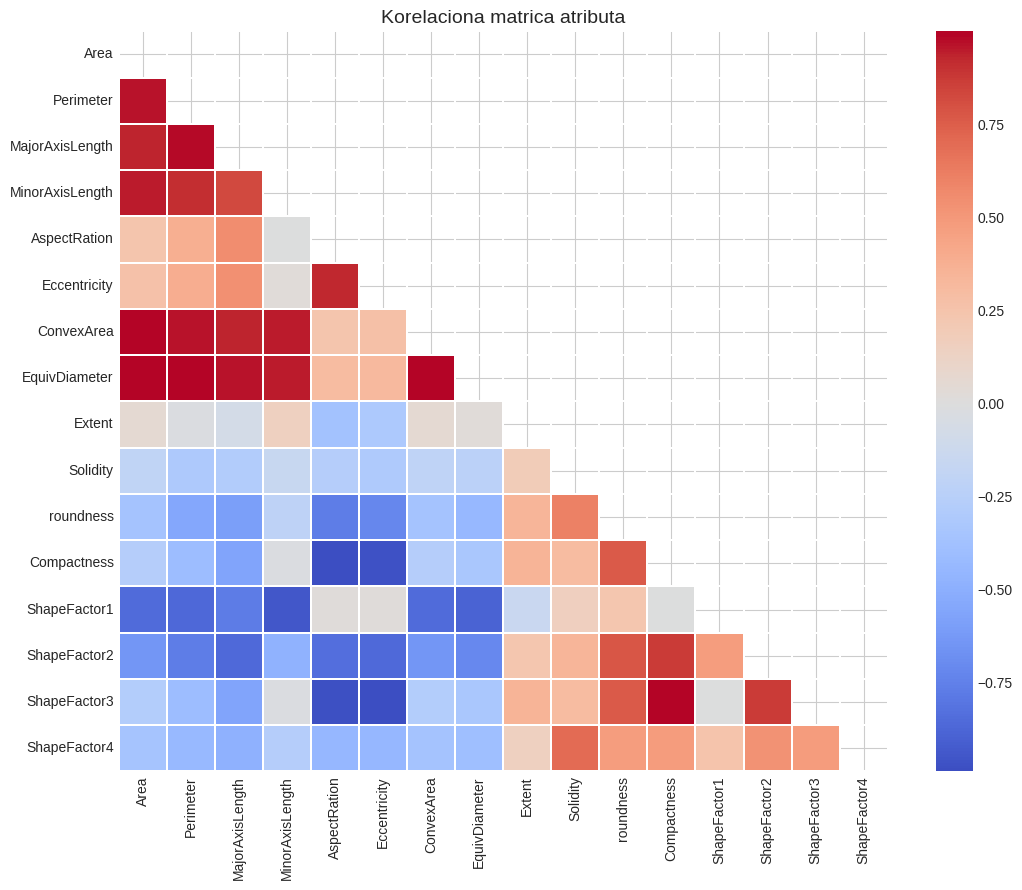

In [68]:
plt.figure(figsize=(11, 9))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # prikazujemo samo donji trougao

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm',
            center=0, linewidths=0.3)
plt.title('Korelaciona matrica atributa', fontsize=14)
plt.tight_layout()
plt.show()


Prva grupa — `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea` i `EquivDiameter` — koji su međusobno jako pozitivno korelisani. Svi oni u suštini mere istu stvar: koliko je zrno veliko.

Druga uočljiva grupa su odličja oblika — `AspectRation`, `Eccentricity` i `ShapeFactor1` — koji su međusobno pozitivno korelisani, a negativno korelisani sa roundness, `Compactness` i `ShapeFactor2`. Ovo ima geometrijski smisao: izduženije zrno nužno ima manju okruglost.

`Extent` i `Solidity` se izdvajaju kao relativno nezavisni od ostalih atributa.

Ovakva struktura — dve jake grupe korelisanih feature-a plus nekoliko nezavisnih — je povoljna situacija za PCA i daje nam razlog da očekujemo da će mali broj komponenti objasniti veliki deo varijanse.

## Box plot atributa po klasama

 Prikazuje se box plot za svaki atribut sa klasama na x-osi, gde tačke van brkova predstavljaju stvarne autlajere unutar svake klase. Ova analiza je značajna i pored detekcije aulajera, za bolji prikaz raspona vrednosti atributa unutar klasa.

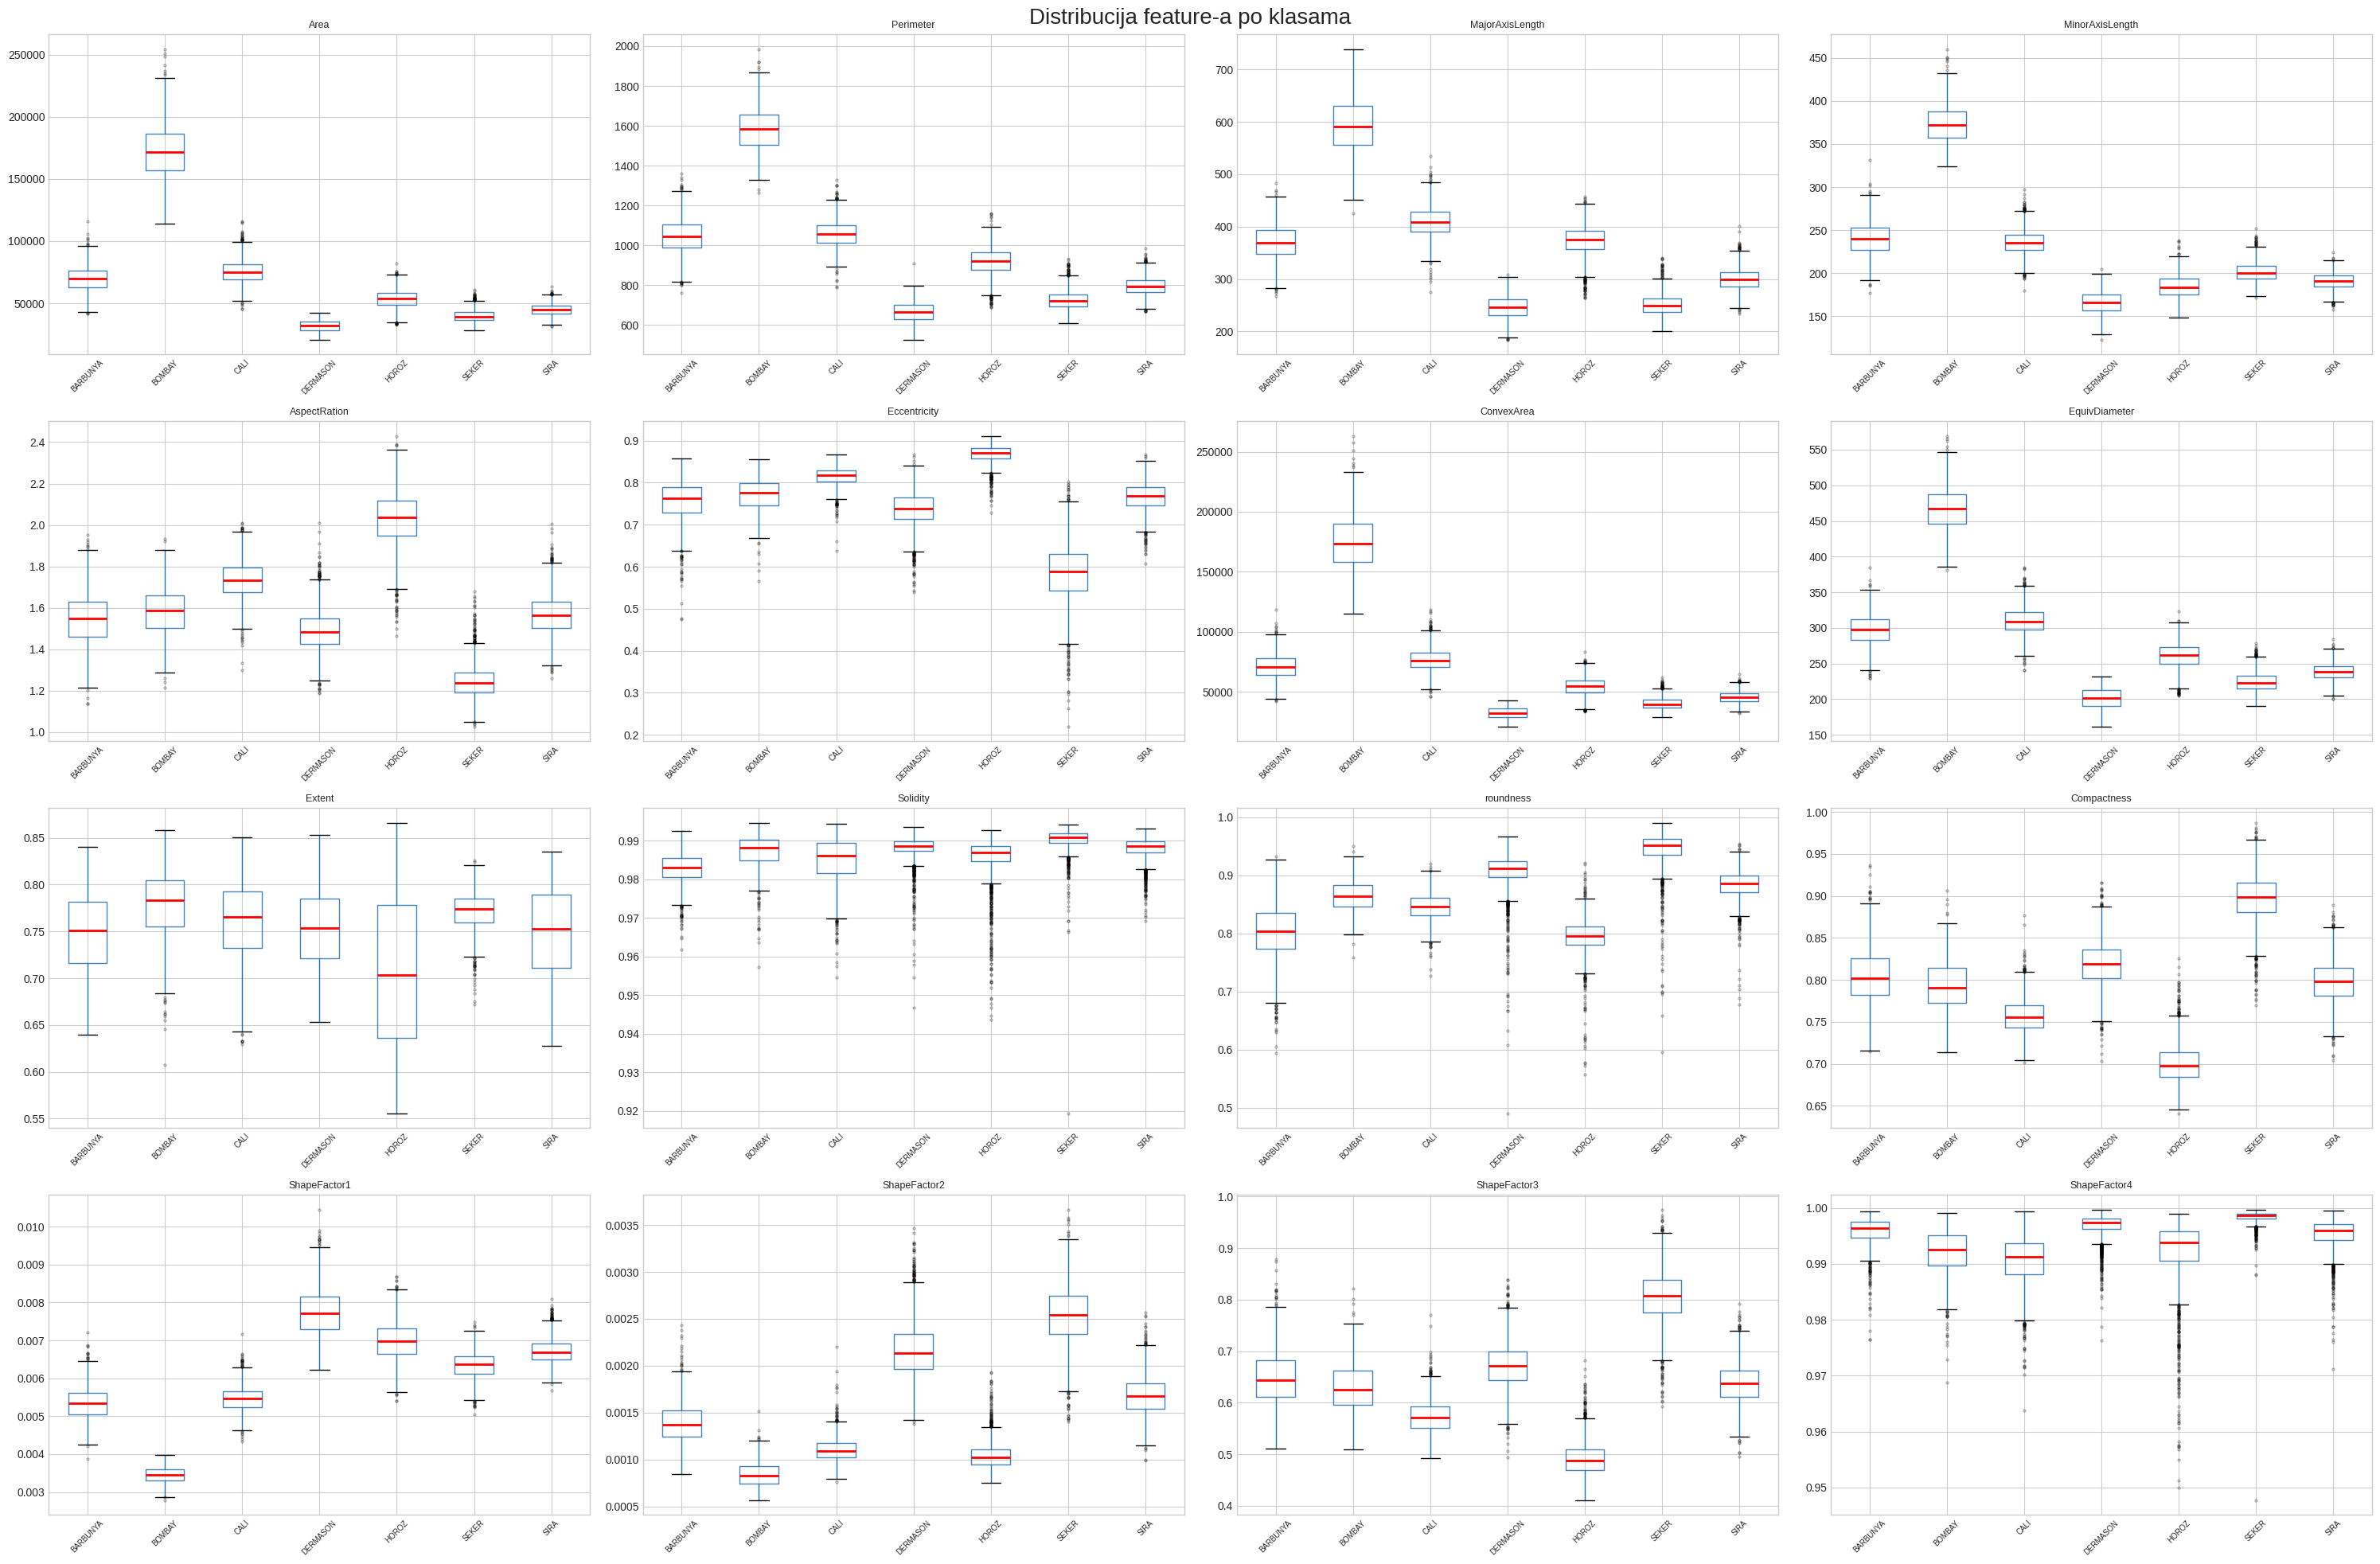

In [69]:
fig, axes = plt.subplots(4, 4, figsize=(30, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Class', ax=axes[i],
               boxprops=dict(color='#4682B4'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=7, rotation=45)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucija feature-a po klasama', fontsize=20)
plt.tight_layout()
plt.show()

`Bombay` odskače kod dimenzijskih feature-a, ali unutar same klase nema puno autlajera. `Extent` je zanimljiv — `Dermason` ima enormno širok box u poređenju sa ostalima, što znači veliki varijabilitet unutar te klase. `Solidity` i `ShapeFactor4` imaju duge brkove nadole kod skoro svih klasa — to su stvarni autlajeri unutar klasa, konzistentno kroz sve. Seker se jasno odvaja po `Eccentricity` i `AspectRation` — box je znatno niži od ostalih, što znači da ima okruglja zrna.

##Analiza srednjih vrednosti atributa po klasama

Kako bismo stekli uvid u to koliko su klase međusobno razdvojive u prostoru feature-a, posmatramo srednje vrednosti svakog feature-a po klasama nakon standardizacije.

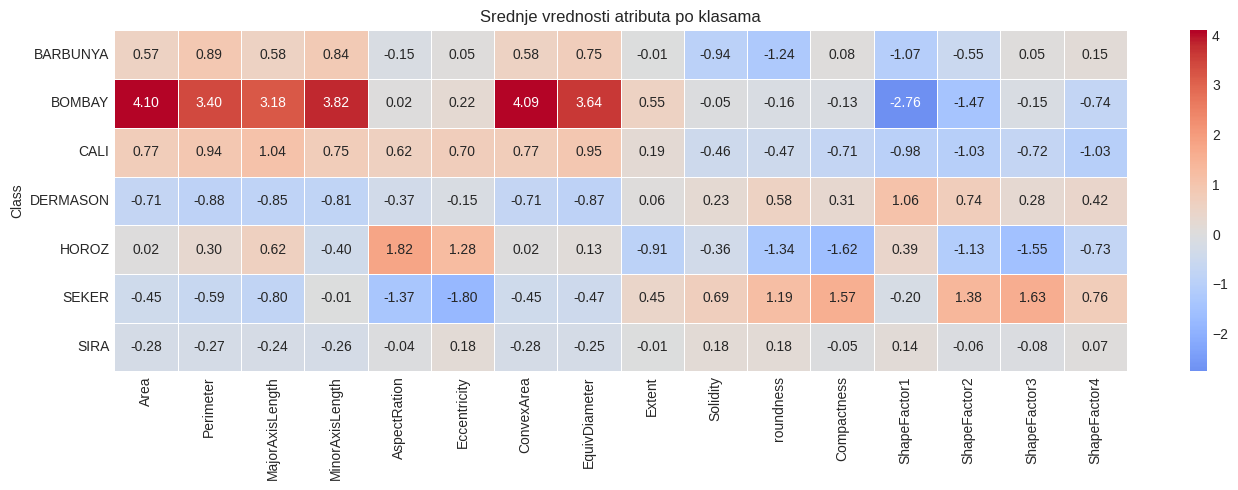

In [70]:
# samo za vizualizaciju heatmapa standardizovacu ceo skup
mean_viz = np.mean(df[num_cols].values, axis=0)
std_viz  = np.std(df[num_cols].values, axis=0)
X_viz = pd.DataFrame((df[num_cols].values - mean_viz) / std_viz, columns=num_cols)
X_viz['Class'] = df['Class'].values
class_means = X_viz.groupby('Class').mean()

plt.figure(figsize=(14, 5))
sns.heatmap(class_means, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Srednje vrednosti atributa po klasama')
plt.tight_layout()
plt.show()

Heatmap otkriva da klase nisu podjednako razdvojive. `Bombay` se potpuno izdvaja, što sugeriše da će klasifikator tu klasu uspešno prepoznati. Sa druge strane, `Barbunya` i `Cali`, kao i `Dermason` i `Sira` pokazuju slične vrednosti za većinu feature-a, što ih čini najizazovnijim parom za klasifikaciju. Ovom analizom smo dobili uvid u potencijalne probleme daljeg rada na ovom skupu podataka.

## Enkodiranje i priprema

In [71]:
le = LabelEncoder()
y  = le.fit_transform(df['Class'])
X  = df[num_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# i za trening i test skup koristimo standardnu devijaciju i ocekivanje sa trening skupa
mean_train = np.mean(X_train, axis=0)
std_train  = np.std(X_train, axis=0)

X_train_sc = (X_train - mean_train) / std_train
X_test_sc  = (X_test  - mean_train) / std_train


In [72]:
print('Train:', X_train_sc.shape, '| Test:', X_test_sc.shape)

Train: (10834, 16) | Test: (2709, 16)


# O sekciji

Na osnovu sprovedene eksplorativne analize može se zaključiti da je skup podataka sada spreman za dalju obradu. Analiza distribucija, korelacija i vrednosti po klasama dala je jasnu sliku strukture podataka: obeležja su grupisana u dve korelisane grupe što direktno motiviše primenu PCA, klase nisu podjednako razdvojive, što postavlja realna očekivanja od klasifikatora. Klasa `Bombay` se izdvaja kao odvojiva, dok su `Barbunya`, `Cali`, `Dermason` i `Sira` potencijalno problematični parovi. Sve ovo uzeto zajedno predstavlja osnovu za implementaciju i evaluaciju PCA i kNN algoritama u narednim sekcijama.

# Principal Component Analysis

## Implementacija funkcija

In [73]:
def center_data(X):
    mean_vec = np.mean(X, axis=0)
    return X - mean_vec, mean_vec

def covariance_matrix(X_centered):
    n = X_centered.shape[0]
    return (X_centered.T @ X_centered) / (n-1)

def project_data(X_centered, W):
    return X_centered @ W

def reconstruct_data(Z, W, mean_vec=None):
    X_hat = Z @ W.T
    if mean_vec is not None:
        X_hat = X_hat + mean_vec
    return X_hat


## Centriranje podataka

In [74]:
# centriramo standardizovane trening podatke
X_centered, mean_vec = center_data(X_train_sc)
print('Mean pre centriranja:  ', np.mean(X_train_sc, axis=0).round(4))
print('Mean posle centriranja:', np.mean(X_centered, axis=0).round(10))


Mean pre centriranja:   [-0. -0. -0.  0. -0.  0.  0.  0.  0.  0. -0.  0. -0. -0. -0. -0.]
Mean posle centriranja: [-0. -0.  0. -0. -0.  0. -0.  0. -0. -0. -0. -0.  0. -0. -0.  0.]


##Kovarijaciona matrica

In [75]:
S = covariance_matrix(X_centered)
print(S)

[[ 1.00009231  0.96718029  0.9323931   0.95251008  0.24330243  0.26831549
   1.00003294  0.98516828  0.04794902 -0.19351704 -0.35953647 -0.26927937
  -0.84921872 -0.6413364  -0.27326793 -0.35129693]
 [ 0.96718029  1.00009231  0.97780966  0.91440662  0.38663681  0.39175863
   0.96816519  0.99167255 -0.02605636 -0.30069822 -0.54828309 -0.40792582
  -0.86620567 -0.76917667 -0.40942572 -0.42542074]
 [ 0.9323931   0.97780966  1.00009231  0.82823026  0.55058708  0.5414397
   0.93319171  0.96226472 -0.08166151 -0.2820443  -0.59794419 -0.56827547
  -0.7765144  -0.8598757  -0.5679866  -0.47885336]
 [ 0.95251008  0.91440662  0.82823026  1.00009231 -0.0052215   0.02257662
   0.95227595  0.94929382  0.13796187 -0.15346479 -0.21309798 -0.0186158
  -0.94717945 -0.4754864  -0.02276247 -0.25953046]
 [ 0.24330243  0.38663681  0.55058708 -0.0052215   1.00009231  0.9241244
   0.24489785  0.30543265 -0.36587848 -0.26899946 -0.76956848 -0.9877348
   0.01953843 -0.83744344 -0.97860946 -0.45191997]
 [ 0.2683

## Sopstvene vrednosti i vektori

In [76]:
# eigh je numericki stabilniji
eigvals, eigvecs = np.linalg.eigh(S)

idx     = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print(eigvals)


[8.88743961e+00 4.21717769e+00 1.28224961e+00 8.21406259e-01
 4.34697703e-01 1.82946081e-01 1.12379009e-01 5.20059190e-02
 8.24662410e-03 1.42390087e-03 1.06360335e-03 2.78886540e-04
 1.48442684e-04 9.65022249e-06 2.17587807e-06 1.79792315e-06]


## Vizualizacija objašnjene varijanse

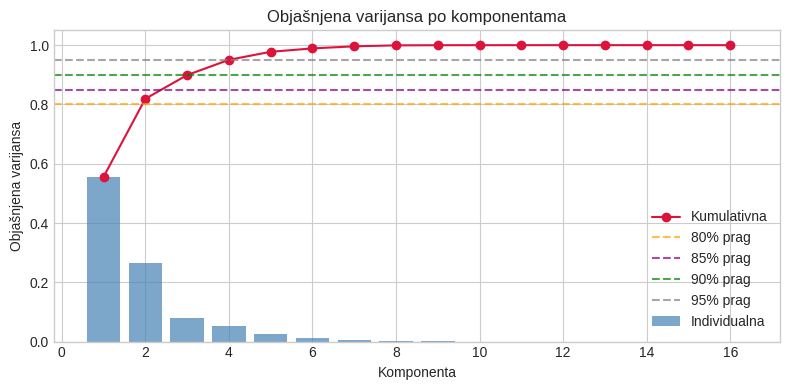

80% varijanse: 2 komponenti
85% varijanse: 3 komponenti
90% varijanse: 4 komponenti
95% varijanse: 4 komponenti


In [77]:
explained_ratio = eigvals / np.sum(eigvals)
cumulative      = np.cumsum(explained_ratio)

thresholds = [0.80, 0.85, 0.90, 0.95]
colors_thr = ['orange', 'purple', 'green', 'gray']

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(eigvals)+1), explained_ratio, label='Individualna', color='steelblue', alpha=0.7)
plt.plot(range(1, len(eigvals)+1), cumulative, marker='o', color='crimson', label='Kumulativna')
for thr, col in zip(thresholds, colors_thr):
    plt.axhline(thr, linestyle='--', color=col, alpha=0.7, label=f'{int(thr*100)}% prag')
plt.xlabel('Komponenta')
plt.ylabel('Objašnjena varijansa')
plt.title('Objašnjena varijansa po komponentama')
plt.legend()
plt.tight_layout()
plt.show()

for thr in thresholds:
    k = np.argmax(cumulative >= thr) + 1
    print(f'{int(thr*100)}% varijanse: {k} komponenti')

n_pca = np.argmax(cumulative >= 0.95) + 1


## Projekcija podataka na prvih 4 komponente

In [78]:
# uzimamo prvih 4 sopstvenih vektora kao matricu projekcije W
W           = eigvecs[:, :n_pca]
X_train_pca = project_data(X_centered, W)

# test skup centriramo istim mean_vec-om kao train (bez data leakage)
X_test_centered = X_test_sc - mean_vec
X_test_pca      = project_data(X_test_centered, W)

print('Train PCA shape:', X_train_pca.shape)
print('Test  PCA shape:', X_test_pca.shape)


Train PCA shape: (10834, 4)
Test  PCA shape: (2709, 4)


## Vizualizacija dve komponente po klasama

Kako bis se vizuelno proverilo da li PCA čuva diskriminativnu informaciju, projektuju se podaci na prve dve komponente koje zajedno nose najveći deo varijanse.

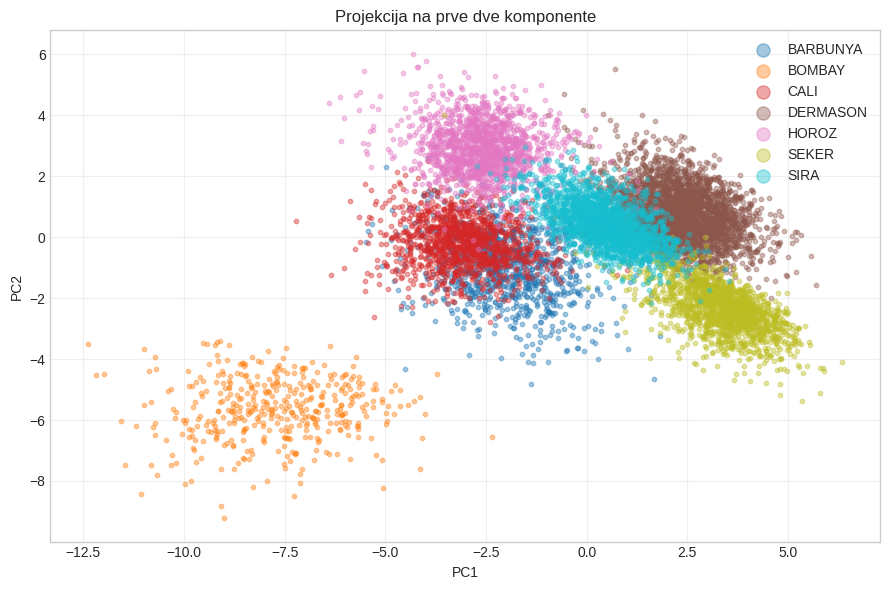

In [79]:
colors = plt.cm.tab10(np.linspace(0, 1, len(le.classes_)))
plt.figure(figsize=(9, 6))
for i, cls in enumerate(le.classes_):
    mask = y_train == i
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                label=cls, alpha=0.4, s=10, color=colors[i])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projekcija na prve dve komponente')
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Na grafiku se vidi da je `Bombay` potpuno odvojena u donjem levom uglu, a `Seker` formira kompaktan klaster u donjem desnom uglu. `Horoz` se izdvaja po PC2 osi naviše. Međutim, `Barbunya`, `Cali`, `Dermason` i `Sira` se značajno preklapaju u centralnom delu, što potvrđuje ranije zapažanje da su te klase najteže za klasifikaciju. Važno je napomenuti da ovo nije potpuna slika — model koristi svih 4 komponenti, a ovde vidimo samo prve dve.

## Vizualizacija tri komponente po klasama

Dodavanjem treće komponente dobijamo potpuniju sliku rasporeda klasa u redukovnom prostoru.

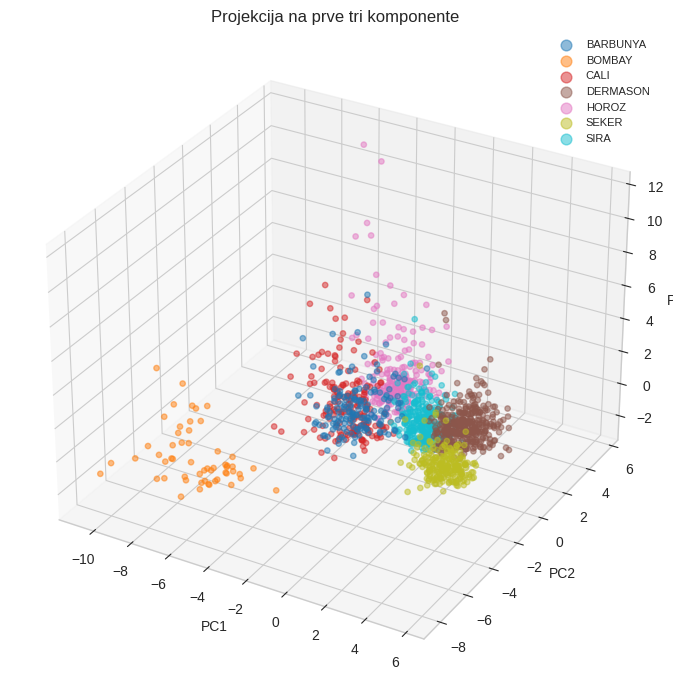

In [80]:
W3     = eigvecs[:, :3]
Z3     = project_data(X_centered, W3)
idx_3d = np.random.choice(len(Z3), 1500, replace=False)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
for i, cls in enumerate(le.classes_):
    mask = y_train[idx_3d] == i
    ax.scatter(Z3[idx_3d][mask, 0], Z3[idx_3d][mask, 1], Z3[idx_3d][mask, 2],
               label=cls, alpha=0.5, s=15, color=colors[i])
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('Projekcija na prve tri komponente')
ax.legend(fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()


U 3D prikazu struktura ostaje slična, `Bombay` je i dalje jasno odvojena,
`Seker` se bolje izdvaja nego u 2D. Međutim preklapanje između `Barbunya`, `Cali`, ` Dermason` i `Sira` i dalje postoji, što znači da treća komponenta ne donosi značajno bolju separabilnost za te klase. Ovo nas priprema na to da kNN neće postići savršenu tačnost.


## Rekonstrukcija i greška

In [81]:
# rekonstrukcija je aproksimativna
X_rec     = reconstruct_data(X_train_pca, W)
rec_error = np.mean(np.sum((X_centered - X_rec) ** 2, axis=1))
print(f'MSE rekonstrukcije ({n_pca} PC): {rec_error:.4f}')
print(f'Objašnjeno varijanse:            {cumulative[n_pca-1]:.2%}')


MSE rekonstrukcije (4 PC): 0.7931
Objašnjeno varijanse:            95.04%


## Grafik greške rekonstrukcije u zavisnosti od broja komponenti

Pored analize objašnjene varijanse, greška rekonstrukcije daje komplementarnu potvrdu izbora broja komponenti.

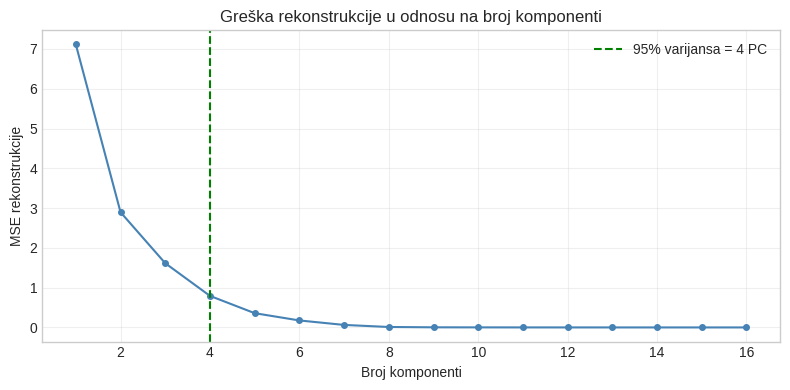

In [82]:
rec_errors = []
for k in range(1, X_train_sc.shape[1] + 1):
    W_k = eigvecs[:, :k]
    Z_k = project_data(X_centered, W_k)
    X_k = reconstruct_data(Z_k, W_k)
    err = np.mean(np.sum((X_centered - X_k) ** 2, axis=1))
    rec_errors.append(err)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(rec_errors)+1), rec_errors, marker='o', markersize=4, color='steelblue')
plt.axvline(n_pca, linestyle='--', color='green', label=f'95% varijansa = {n_pca} PC')
plt.xlabel('Broj komponenti')
plt.ylabel('MSE rekonstrukcije')
plt.title('Greška rekonstrukcije u odnosu na broj komponenti')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Kriva pokazuje nagli pad greške do četvrte komponente, nakon čega se praktično izravnava. To znači da svaka dodatna komponenta posle četvrte donosi zanemarljivo smanjenje greške rekonstrukcije, što potvrđuje da je izbor od 4 komponente opravdan i sa ovog stanovišta.



## Grafici doprinosa originalnih atributa

Loadings grafici otkrivaju šta svaka od četiri zadržane komponente predstavlja u fizičkom smislu.

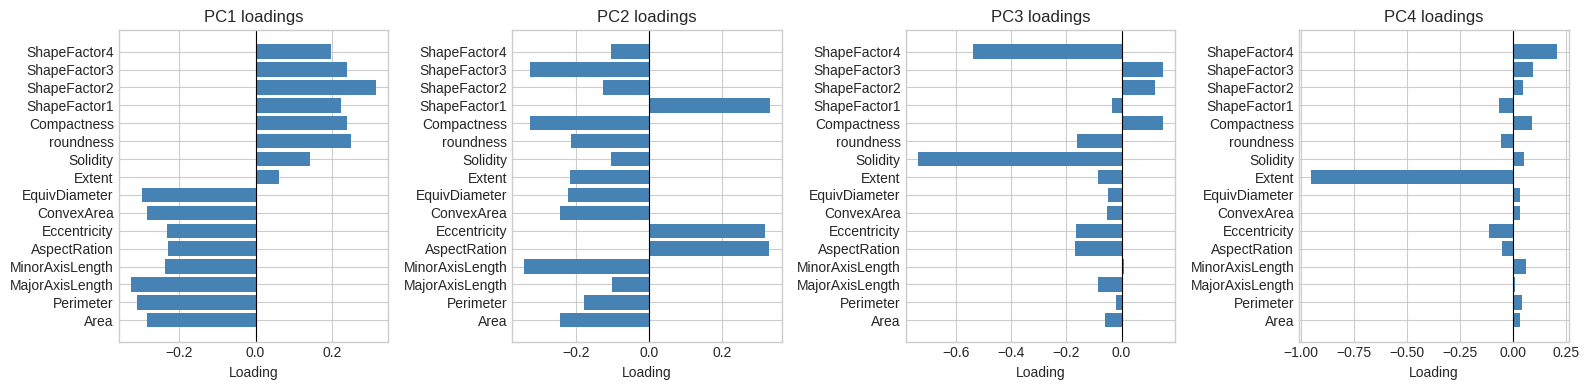

In [83]:
fig, axes = plt.subplots(1, n_pca, figsize=(n_pca*4, 4))
for i, ax in enumerate(axes):
    ax.barh(num_cols, eigvecs[:, i], color='steelblue')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'PC{i+1} loadings')
    ax.set_xlabel('Loading')
plt.tight_layout()
plt.show()



Pozitivni loading znači da kada vrednost tog atributa raste, koordinata uzorka po toj PC komponenti takođe raste — kreću se u istom smeru. Negativni loading znači suprotno — kada vrednost atributa raste, koordinata po toj PC komponenti opada.

Prva komponenta nosi najveći deo varijanse i opisuje veličinu zrna — dimenzijski atributi poput `Area`, `Perimeter`, `MajorAxisLength` i `ConvexArea` imaju negativne loadings, dok atributi oblika poput `roundness`, `Compactness` i `ShapeFactor1/2/3` imaju pozitivne. Upravo zbog toga je `Bombay`, kao najveća vrsta, tako jasno odvojena po PC1 osi u projekciji.

Druga komponenta opisuje izduženost zrna — `AspectRation` i `Eccentricity` dominiraju sa pozitivnim loadings-ima, a `ShapeFactor1` negativno. Visoke vrednosti po PC2 odgovaraju duguljastim zrnima, koja nisu okrugla, što objašnjava zašto se `Horoz`, kao najizduženija vrsta, izdvaja naviše po ovoj osi.

Treća komponenta je dominirana negativnim loading-om atributa `Solidity`, koji meri koliko je kontura zrna pravilna i popunjena bez udubljenja. PC3 dakle hvata nepravilnost oblika konture i donosi informaciju koju prve dve komponente nisu pokrile.

Četvrta komponenta je definisana pretežno atributom `Extent`, koji meri koliko zrno popunjava svoj bounding box. Ova komponenta opisuje prostornu kompaktnost zrna i zaokružuje interpretaciju redukovnog prostora.

## Primena logaritamske transformacije

Na osnovu grafika raspodela, pojavila se ideja da bi logaritamska transformacija uticala na veću uspešnost PCA.

In [84]:
skewness = df.drop('Class', axis=1).skew().sort_values()
print(skewness)

ShapeFactor4      -2.760125
Solidity          -2.546877
Eccentricity      -1.064932
Extent            -0.895655
roundness         -0.648725
ShapeFactor1      -0.530427
Compactness        0.036309
ShapeFactor3       0.242767
ShapeFactor2       0.294332
AspectRation       0.589045
MajorAxisLength    1.365813
Perimeter          1.628018
EquivDiameter      1.947303
MinorAxisLength    2.232013
ConvexArea         2.936102
Area               2.947136
dtype: float64


Atributi `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea` i `EquivDiameter` pokazuju jaku pozitivnu asimetriju (do 2.95). Primenjujemo log transformaciju na ove atribute i ponavljamo PCA kako bismo empirijski utvrdili da li transformacija donosi poboljšanje u odnosu na standardizaciju bez nje.

In [85]:
# log transformacija samo na atributima sa jakom asimetrijom
log_cols = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter']

df_log = df.copy()
df_log[log_cols] = np.log(df_log[log_cols])

# standardizacija od nule — isti postupak kao pre
X_log = df_log[num_cols].values
X_train_log, X_test_log, _, _ = train_test_split(X_log, y, test_size=0.2, random_state=42, stratify=y)

mean_log = np.mean(X_train_log, axis=0)
std_log  = np.std(X_train_log, axis=0)
X_train_log_sc = (X_train_log - mean_log) / std_log
X_test_log_sc  = (X_test_log  - mean_log) / std_log


## PCA na log transformisanim podacima

Isti postupak kao i pre — centriranje, kovarijaciona matrica, eigen-dekompozicija. Pratimo da li se broj komponenti potrebnih za 95% varijanse razlikuje.

In [86]:
X_log_centered, mean_vec_log = center_data(X_train_log_sc)
S_log = covariance_matrix(X_log_centered)

eigvals_log, eigvecs_log = np.linalg.eigh(S_log)
idx_log     = np.argsort(eigvals_log)[::-1]
eigvals_log = eigvals_log[idx_log]
eigvecs_log = eigvecs_log[:, idx_log]

explained_log  = eigvals_log / np.sum(eigvals_log)
cumulative_log = np.cumsum(explained_log)

n_pca_log = np.argmax(cumulative_log >= 0.95) + 1
print(f'Bez log — broj komponenti za 95%: {n_pca}')
print(f'Sa log  — broj komponenti za 95%: {n_pca_log}')


Bez log — broj komponenti za 95%: 4
Sa log  — broj komponenti za 95%: 4


## Poređenje objašnjene varijanse

Poredimo kako je varijansa raspoređena po komponentama u oba slučaja. Ako log transformacija poboljšava rezultate, očekujemo ravnomerniju raspodelu varijanse — manje dominantna prva komponenta znači da PCA bolje hvata strukturu podataka.

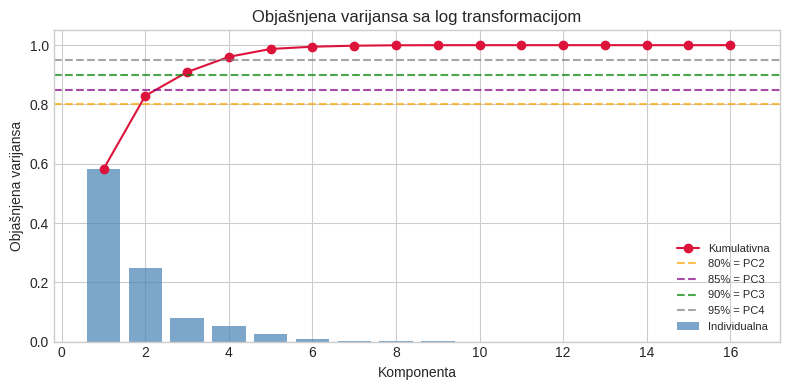

80% varijanse: 2 komponenti
85% varijanse: 3 komponenti
90% varijanse: 3 komponenti
95% varijanse: 4 komponenti


In [87]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained_log)+1), explained_log, color='steelblue', alpha=0.7, label='Individualna')
ax.plot(range(1, len(cumulative_log)+1), cumulative_log, marker='o', color='crimson', label='Kumulativna')
for thr, col in zip(thresholds, colors_thr):
    k = np.argmax(cumulative_log >= thr) + 1
    ax.axhline(thr, linestyle='--', color=col, alpha=0.7, label=f'{int(thr*100)}% = PC{k}')
ax.set_xlabel('Komponenta')
ax.set_ylabel('Objašnjena varijansa')
ax.set_title('Objašnjena varijansa sa log transformacijom')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for thr in thresholds:
    k = np.argmax(cumulative_log >= thr) + 1
    print(f'{int(thr*100)}% varijanse: {k} komponenti')

Log transformacija primenjena na atribute sa jakom pozitivnom asimetrijom (`Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `ConvexArea`, `EquivDiameter`) nije donela značajno poboljšanje u PCA analizi. Broj komponenti potrebnih za objašnjavanje 95% varijanse ostao je isti, a raspodela varijanse po komponentama je praktično identična u oba slučaja, sa prvom komponentom koja nosi oko 58% varijanse. Na osnovu ovoga zaključujemo da je standardizacija dovoljna predobrada i da log transformacija neće biti primenjivana u daljem radu.


# O sekciji

PCA uspešno je redukovala dimenzionalnost skupa uz zadržavanje 95% varijanse. Četiri glavne komponente nose interpretabilno značenje — veličinu, izduženost, pravilnost konture i prostornu kompaktnost zrna — što potvrđuje da redukcija nije samo matematička već i smislena. Projekcije u 2D i 3D prostoru potvrđuju ranije zaključke o separabilnosti klasa, a log transformacija nije donela poboljšanje.

# k Nearest Neighbours